Compare the model performances

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import json

import os
from pathlib import Path

In [71]:
def parse_metrics(root_dir):
    all_dataset_results = {
        #"Composite":{},
        "Composite-k16":{},
        "Composite-k30":{},
        "NormExpression":{},
        "RawExpression":{}
    }
    root_path = Path(root_dir)
    for json_file in root_path.rglob('*.json'):
        # get folder name
        folder_name = json_file.parent.name
        file_name = json_file.name

        try:
            # split model name and dataset name
            name_list = folder_name.split('_')
            
            dataset_name = name_list.pop()
            model_name = '_'.join(name_list)
            #print(model_name)

            # load metrics
            with open(json_file,'r') as f:
                metrics = json.load(f)
            if 'test_metrics' in metrics: metrics = metrics['test_metrics']
            all_dataset_results[dataset_name][model_name]= metrics

        except (ValueError, json.JSONDecodeError) as e:
            print(f"skipping {folder_name}: {e}")
    return all_dataset_results

In [72]:
all_dataset_metrics = parse_metrics('../results')

composite_df = pd.DataFrame(all_dataset_metrics['Composite-k16'])
composite_df = composite_df.T
composite_df

,Accuracy,Precision,Recall,F1-Score,AUROC
fuzzy_gat,0.945946,1.000000,0.911111,0.953488,0.986973
baseline_gat,0.675676,0.661538,0.955556,0.781818,0.629885
ml_SVM,0.671141,0.671141,1.000000,0.803213,0.527143
ml_LogisticRegression,0.335570,0.571429,0.040000,0.074766,0.473469
fuzzy_gin,0.918919,0.953488,0.911111,0.931818,0.970881
ml_RandomForest,0.577181,0.655462,0.780000,0.712329,0.401633
baseline_gin,0.662162,0.692308,0.800000,0.742268,0.737931
baseline_gcn,0.729730,0.692308,1.000000,0.818182,0.729502
fuzzy_gcn,0.918919,0.975610,0.888889,0.930233,0.961686


### Visulization

In [49]:
def categorize(name):
    if 'fuzzy' in name: return 'Fuzzy GNN'
    if 'baseline' in name: return 'Baseline GNN'
    return 'ML Models'

In [63]:
composite_df['Category'] = composite_df['Model'].apply(categorize)
composite_df['Architecture'] = composite_df['Model'].apply(lambda x: x.split('_')[-1])
composite_df = composite_df.sort_values(by='Model', ascending=False)
composite_df

,Accuracy,Precision,Recall,F1-Score,AUROC,Model,Category,Architecture
ml_SVM,0.671141,0.671141,1.000000,0.803213,0.527143,ml_SVM,ML Models,SVM
ml_RandomForest,0.577181,0.655462,0.780000,0.712329,0.401633,ml_RandomForest,ML Models,RandomForest
ml_LogisticRegression,0.335570,0.571429,0.040000,0.074766,0.473469,ml_LogisticRegression,ML Models,LogisticRegression
fuzzy_gin,0.918919,0.953488,0.911111,0.931818,0.970881,fuzzy_gin,Fuzzy GNN,gin
fuzzy_gcn,0.918919,0.975610,0.888889,0.930233,0.961686,fuzzy_gcn,Fuzzy GNN,gcn
fuzzy_gat,0.945946,1.000000,0.911111,0.953488,0.986973,fuzzy_gat,Fuzzy GNN,gat
baseline_gin,0.662162,0.692308,0.800000,0.742268,0.737931,baseline_gin,Baseline GNN,gin
baseline_gcn,0.729730,0.692308,1.000000,0.818182,0.729502,baseline_gcn,Baseline GNN,gcn
baseline_gat,0.675676,0.661538,0.955556,0.781818,0.629885,baseline_gat,Baseline GNN,gat


In [75]:
def plot_metrics(df, dataset:str, output:str):
    
    metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUROC"]
    category_order = ['Baseline GNN', 'Fuzzy GNN', 'ML Models']
    architecture_order = ['gat', 'gcn', 'gin', 'SVM', 'RandomForest', 'LogisticRegression']

    # Initialize the figure and the grid
    # 5 metrics, so a 2x3 grid  (with one empty slot to place legend)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten() # Flatten the 2D array to 1D for easy looping

    sns.set_theme(style="whitegrid")

    # loop through metrics and create a subplot for each
    for i, metric in enumerate(metrics):
        sns.barplot(
            data=df, 
            x="Category", 
            y=metric, 
            hue="Architecture", 
            ax=axes[i], 
            palette="magma",
            order=category_order,      # keep x-axis groups centered
            hue_order=architecture_order # keep bars aligh wih group
        )
        
        axes[i].set_title(f'{metric}', fontsize=14, fontweight='bold')
        axes[i].set_ylim(0, 1.1)
        axes[i].set_xlabel("") # Remove x-label for cleaner look
        axes[i].get_legend().remove() # Remove individual legends to add one global one later

    # clean up the empty subplot (the 6th slot)
    ax_leg = axes[5]
    ax_leg.axis('off')

    # add a single global legend to the side
    handles, labels = axes[0].get_legend_handles_labels()
    # place legend exactly in the middle of the 6th slot
    ax_leg.legend(
        handles, 
        labels, 
        loc='center', 
        title='Models', 
        title_fontsize='18', 
        fontsize='16',
        frameon=True
    )
    # Output
    plt.suptitle(f'Comparison of Model Performance across All Metrics of Data {dataset}', fontsize=20, y=0.95)
    plt.tight_layout(rect=[0, 0.03, 0.9, 0.92]) # Make room for the legend and title
    plt.savefig(output, dpi=300)
    plt.show()

Composite-k16


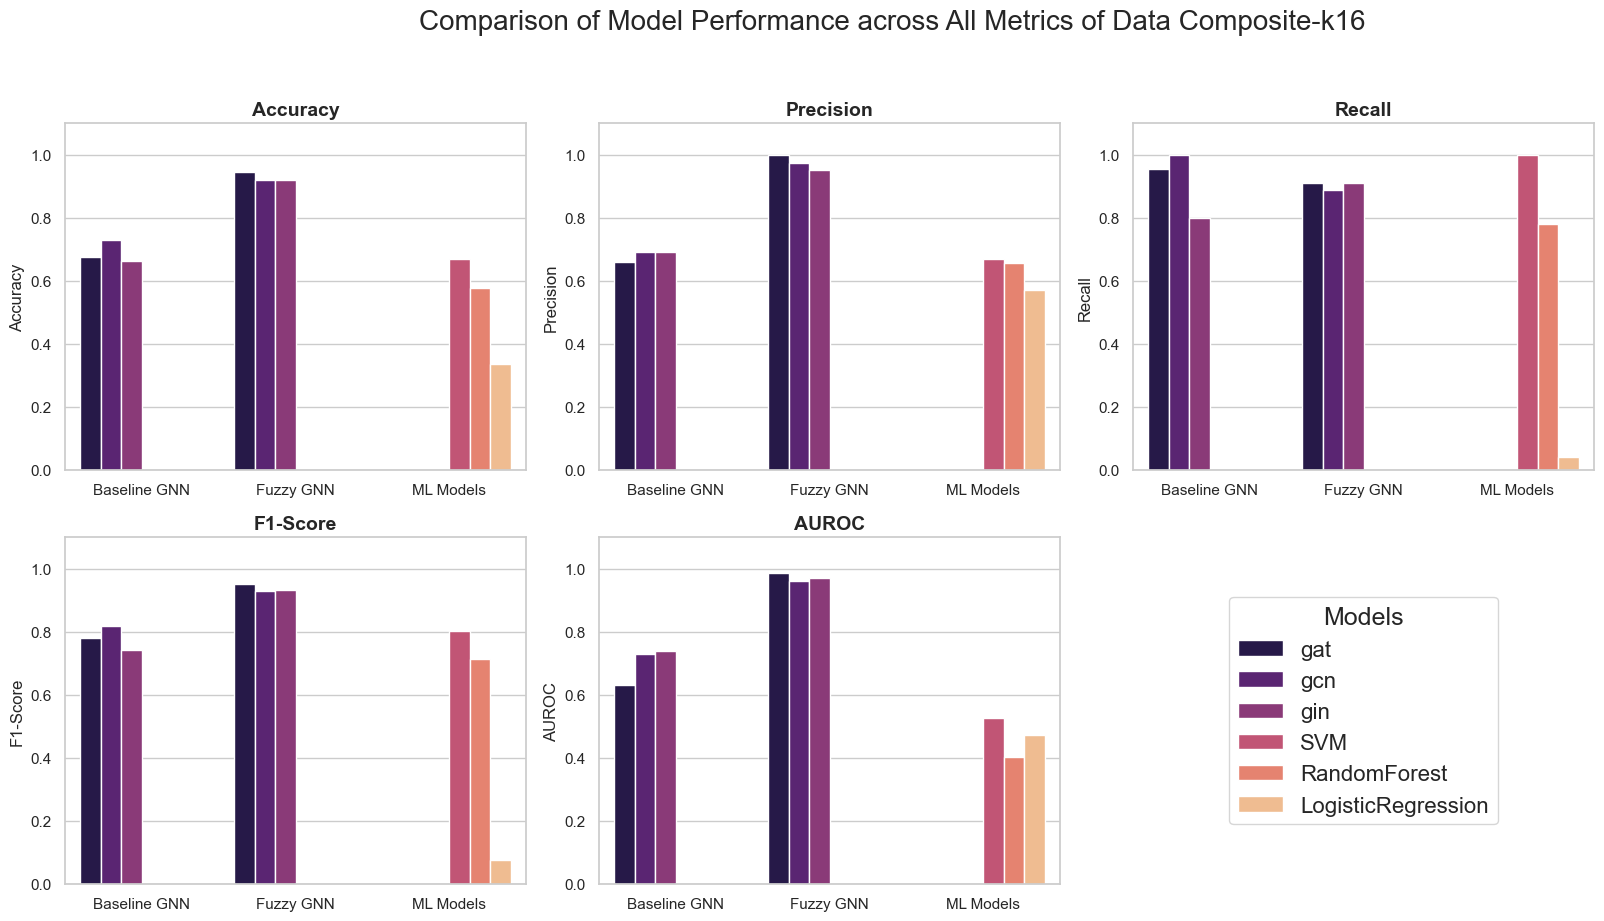

Composite-k30


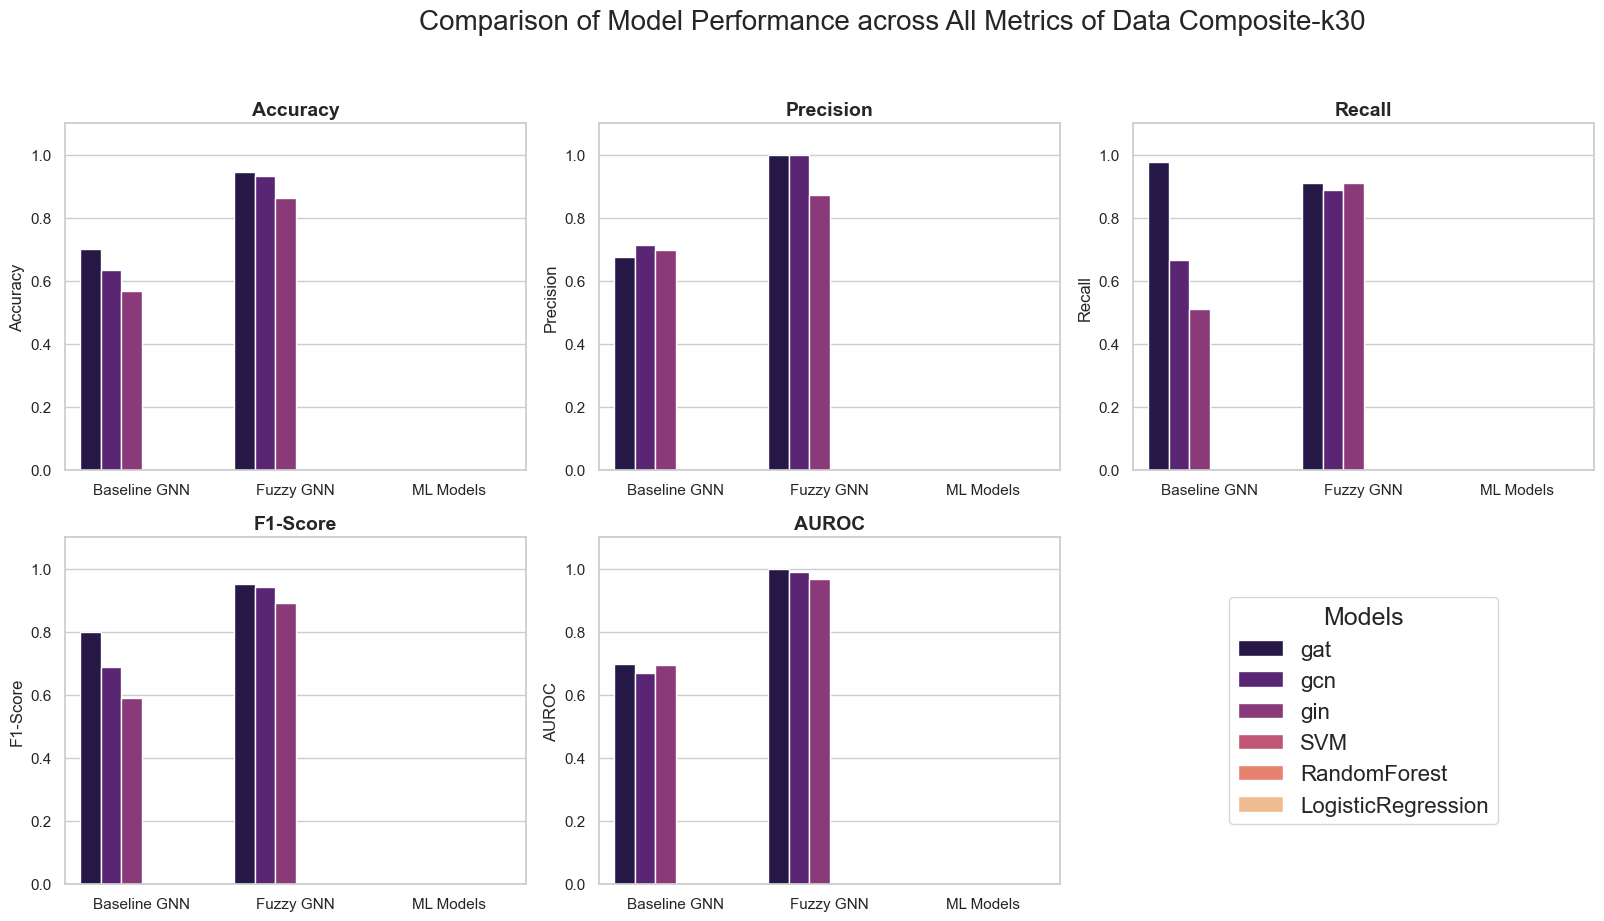

NormExpression


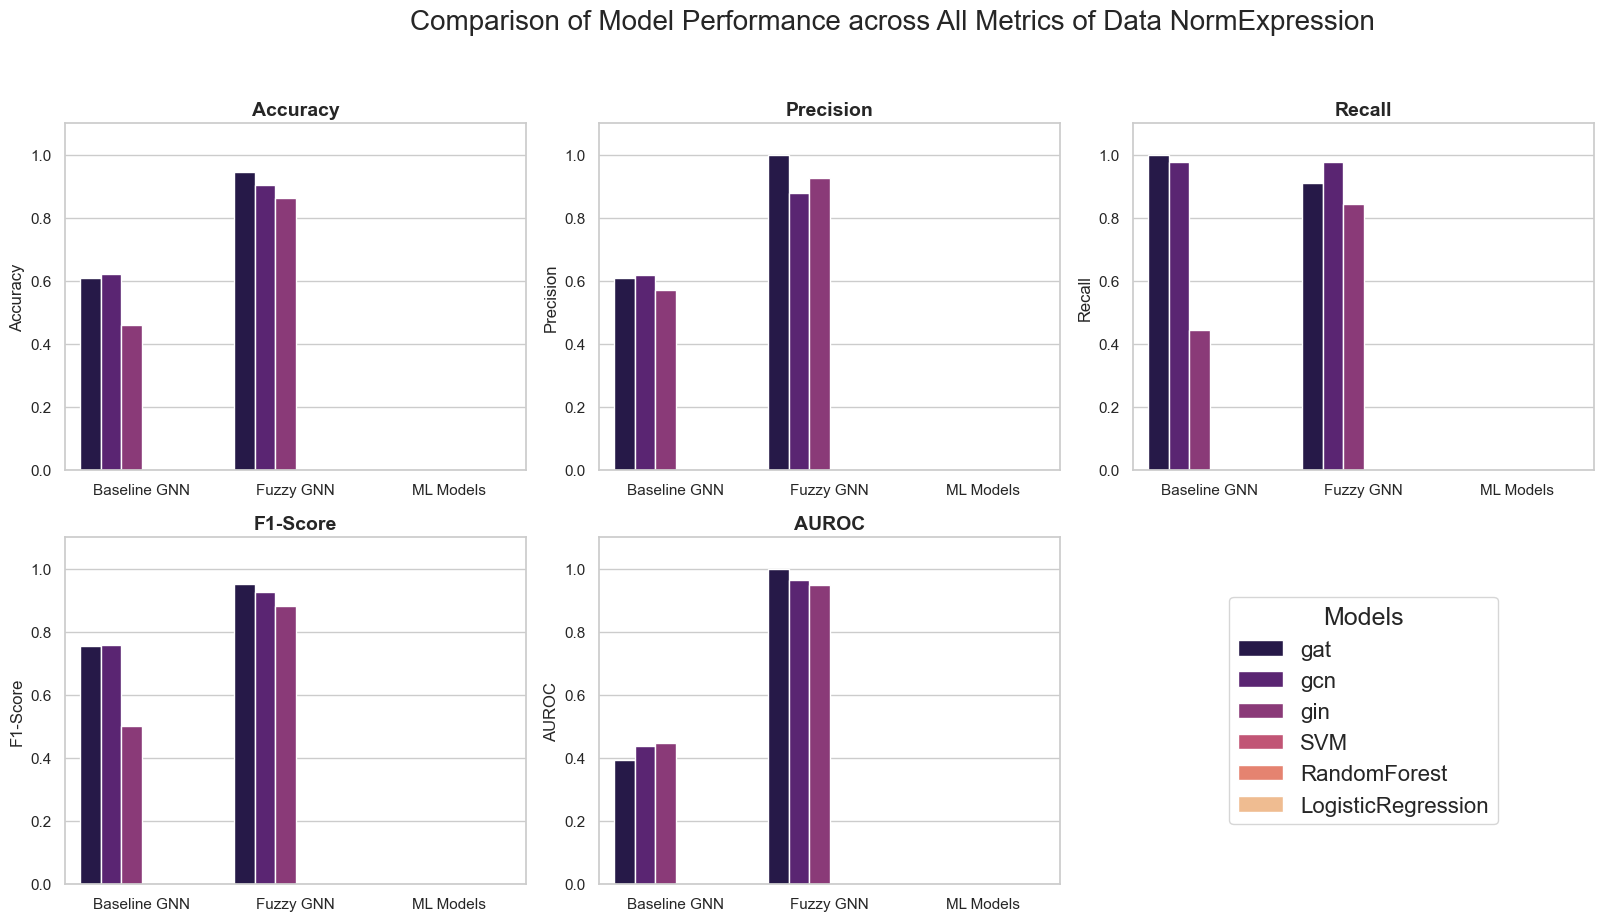

RawExpression


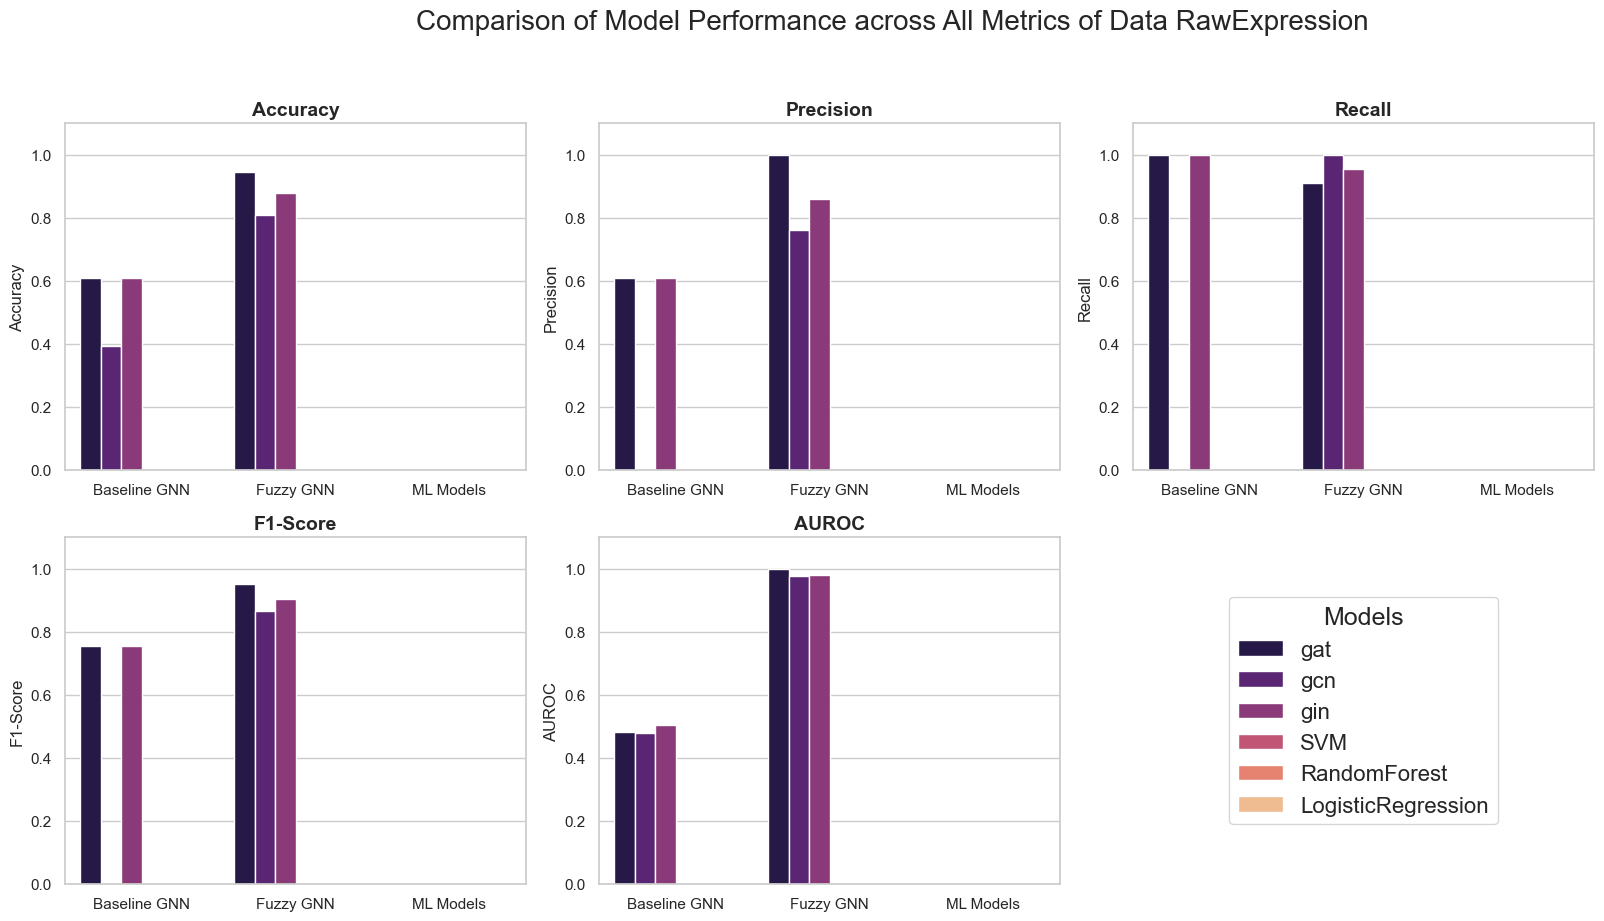

In [76]:
for dataset_name in all_dataset_metrics.keys():
    print(dataset_name)
    #print(all_dataset_metrics[dataset_name])
    df = pd.DataFrame(all_dataset_metrics[dataset_name]).T
    # group the models in df
    df['Model'] = df.index
    df['Category'] = df['Model'].apply(categorize)
    df['Architecture'] = df['Model'].apply(lambda x: x.split('_')[-1])

    plot_metrics(df, dataset_name, f'metrics_{dataset_name}.png')
    

In [77]:
all_dataset_metrics

{'Composite-k16': {'fuzzy_gat': {'Accuracy': 0.9459459459459459,
   'Precision': 1.0,
   'Recall': 0.9111111111111111,
   'F1-Score': 0.9534883720930233,
   'AUROC': 0.9869731800766284},
  'baseline_gat': {'Accuracy': 0.6756756756756757,
   'Precision': 0.6615384615384615,
   'Recall': 0.9555555555555556,
   'F1-Score': 0.7818181818181819,
   'AUROC': 0.6298850574712643},
  'ml_SVM': {'Accuracy': 0.6711409395973155,
   'Precision': 0.6711409395973155,
   'Recall': 1.0,
   'F1-Score': 0.8032128514056225,
   'AUROC': 0.5271428571428571},
  'ml_LogisticRegression': {'Accuracy': 0.33557046979865773,
   'Precision': 0.5714285714285714,
   'Recall': 0.04,
   'F1-Score': 0.07476635514018691,
   'AUROC': 0.47346938775510206},
  'fuzzy_gin': {'Accuracy': 0.918918918918919,
   'Precision': 0.9534883720930233,
   'Recall': 0.9111111111111111,
   'F1-Score': 0.9318181818181818,
   'AUROC': 0.9708812260536399},
  'ml_RandomForest': {'Accuracy': 0.5771812080536913,
   'Precision': 0.6554621848739496

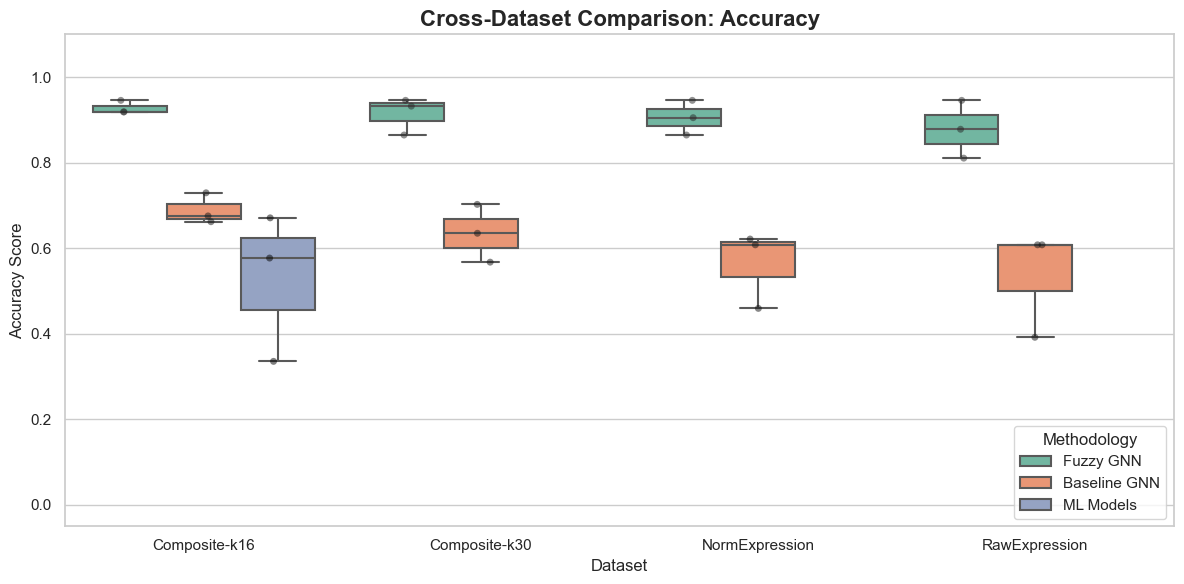

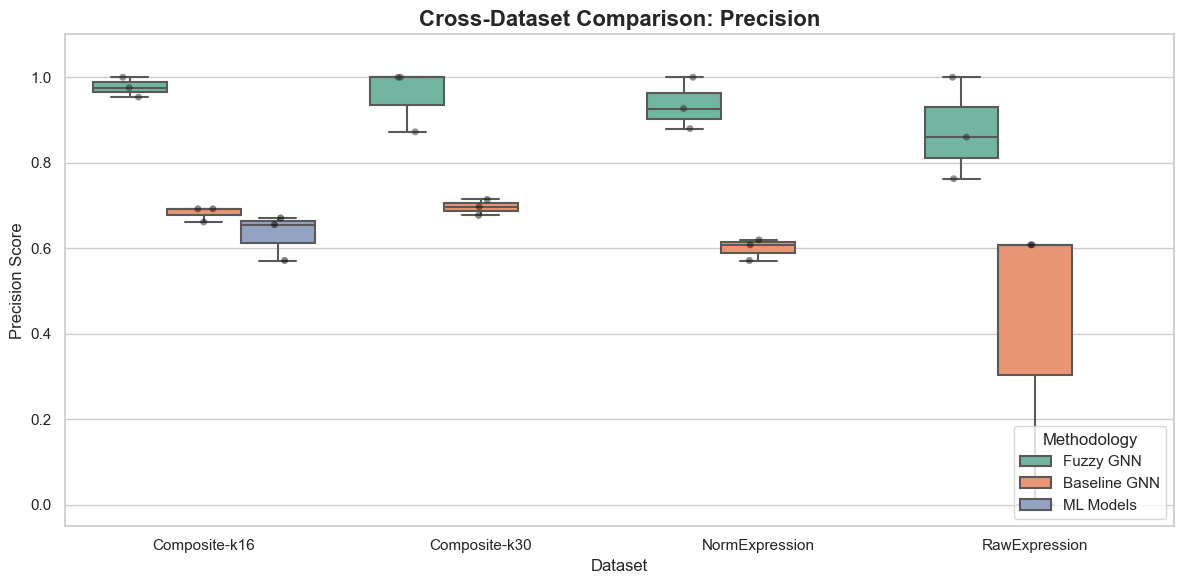

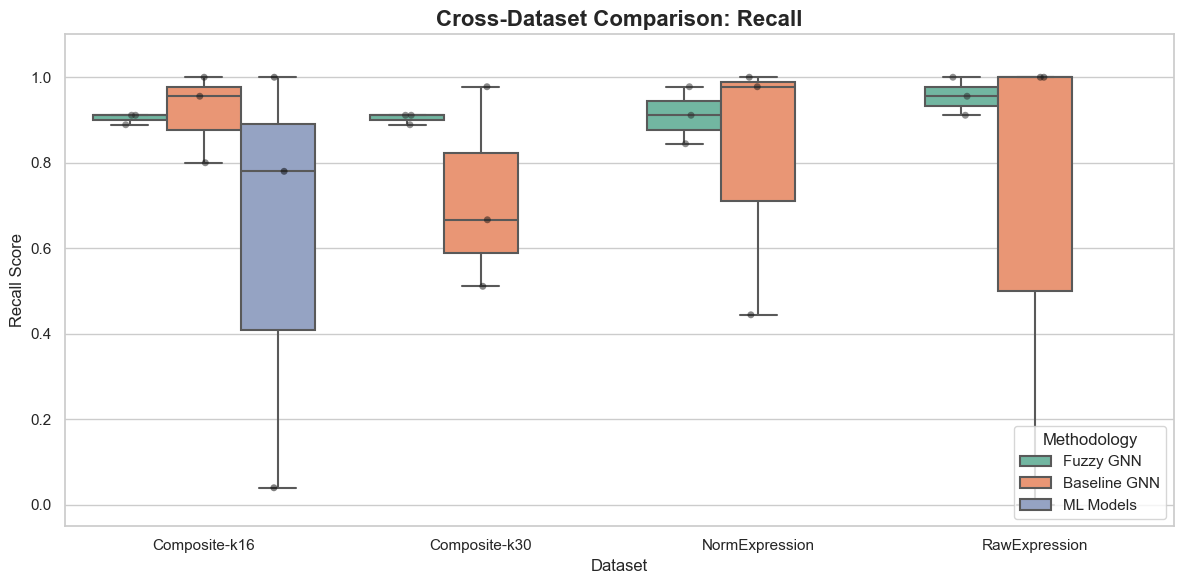

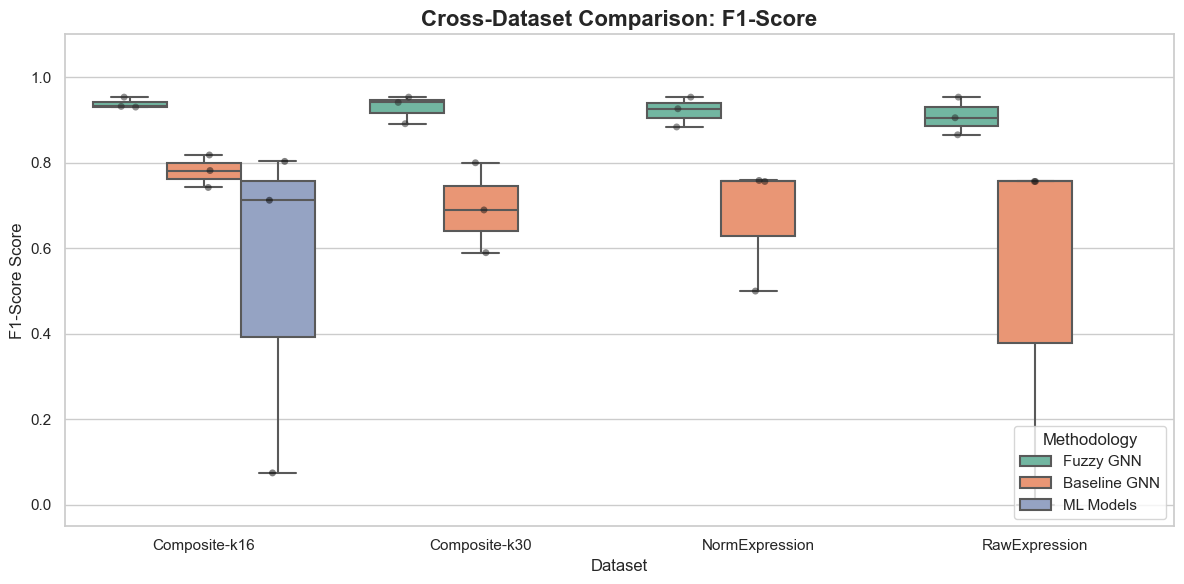

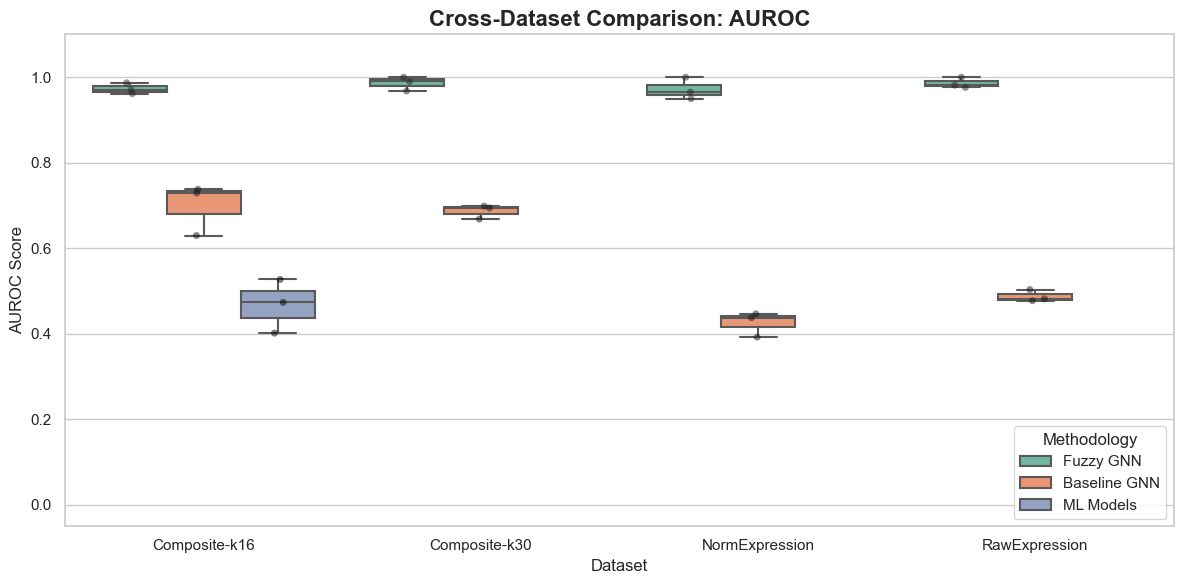

In [78]:
# 1. Transform Dictionary to Long-Form DataFrame
metrics_dict = all_dataset_metrics

rows = []
for dataset, models in metrics_dict.items():
    for model_name, metrics in models.items():
        # Determine Category
        if 'fuzzy' in model_name: category = 'Fuzzy GNN'
        elif 'baseline' in model_name: category = 'Baseline GNN'
        else: category = 'ML Models'
        
        for metric_name, value in metrics.items():
            rows.append({
                'Dataset': dataset,
                'Model': model_name,
                'Category': category,
                'Metric': metric_name,
                'Value': value
            })

df_long = pd.DataFrame(rows)

# 2. Setup Plotting Environment
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUROC"]
sns.set_theme(style="whitegrid")

# Create a figure for each metric (as requested)
for metric in metrics:
    plt.figure(figsize=(12, 6))
    metric_df = df_long[df_long['Metric'] == metric]
    
    # x = Dataset, y = Performance Value, hue = Category
    # This shows how categories compare across datasets
    sns.boxplot(
        data=metric_df, 
        x="Dataset", 
        y="Value", 
        hue="Category",
        palette="Set2",
        linewidth=1.5
    )
    
    # Add individual points to show specific model positions (optional but helpful)
    sns.stripplot(
        data=metric_df, 
        x="Dataset", 
        y="Value", 
        hue="Category", 
        dodge=True, 
        alpha=0.5, 
        palette="dark:black",
        legend=False
    )
    
    plt.title(f'Cross-Dataset Comparison: {metric}', fontsize=16, fontweight='bold')
    plt.ylabel(f'{metric} Score')
    plt.ylim(-0.05, 1.1)
    plt.legend(title='Methodology', loc='lower right')
    plt.tight_layout()
    plt.show()

In [81]:
print(df_long)

           Dataset      Model   Category     Metric     Value
0    Composite-k16  fuzzy_gat  Fuzzy GNN   Accuracy  0.945946
1    Composite-k16  fuzzy_gat  Fuzzy GNN  Precision  1.000000
2    Composite-k16  fuzzy_gat  Fuzzy GNN     Recall  0.911111
3    Composite-k16  fuzzy_gat  Fuzzy GNN   F1-Score  0.953488
4    Composite-k16  fuzzy_gat  Fuzzy GNN      AUROC  0.986973
..             ...        ...        ...        ...       ...
130  RawExpression  fuzzy_gin  Fuzzy GNN   Accuracy  0.878378
131  RawExpression  fuzzy_gin  Fuzzy GNN  Precision  0.860000
132  RawExpression  fuzzy_gin  Fuzzy GNN     Recall  0.955556
133  RawExpression  fuzzy_gin  Fuzzy GNN   F1-Score  0.905263
134  RawExpression  fuzzy_gin  Fuzzy GNN      AUROC  0.981609

[135 rows x 5 columns]


In [87]:
rows = []
for dataset, models in metrics_dict.items():
    for model_name, metrics in models.items():
        # 1. Determine Category
        if 'fuzzy' in model_name: category = 'Fuzzy GNN'
        elif 'baseline' in model_name: category = 'Baseline GNN'
        else: category = 'ML Models'
        
        # 2. Extract clean Architecture name (e.g., 'fuzzy_gat' -> 'gat')
        # This creates the missing "Architecture" column
        arch = model_name.split('_')[-1] 
        
        for metric_name, value in metrics.items():
            rows.append({
                'Dataset': dataset,
                'Model': model_name,
                'Category': category,
                'Architecture': arch,  # <--- MUST INCLUDE THIS
                'Metric': metric_name,
                'Value': value
            })

df_long = pd.DataFrame(rows)
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUROC"]
categories = ['Fuzzy GNN', 'Baseline GNN', 'ML Models']
dataset_order = ['Composite-k16', 'Composite-k30', 'NormExpression', 'RawExpression']

subset = df_long[(df_long['Metric'] == 'Accuracy') & (df_long['Category'] == "ML Models")]
subset

,Dataset,Model,Category,Architecture,Metric,Value
10,Composite-k16,ml_SVM,ML Models,SVM,Accuracy,0.671141
15,Composite-k16,ml_LogisticRegression,ML Models,LogisticRegression,Accuracy,0.335570
25,Composite-k16,ml_RandomForest,ML Models,RandomForest,Accuracy,0.577181


In [ ]:
for metric in metrics:
    # Create a 1x3 figure for the current metric
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
    
    for i, cat in enumerate(categories):

        # Filter data for this specific subplot
        subset = df_long[(df_long['Metric'] == metric) & (df_long['Category'] == cat)]
        
        # Plot: Dataset on X-axis, Model Architecture as the bars
        sns.barplot(
            data=subset,
            x="Dataset",
            y="Value",
            hue="Architecture",
            ax=axes[i],
            palette="viridis",
            order=dataset_order
        )
        
        axes[i].set_title(f'{cat}: {metric}', fontsize=14, fontweight='bold')
        axes[i].set_ylim(0, 1.1)
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
        axes[i].set_xlabel("")
        if i > 0: axes[i].set_ylabel("") # Only show Y-label on the first subplot
        
        # Move legend to a consistent spot
        axes[i].legend(title="Model", loc='lower right', fontsize='small')

    plt.suptitle(f'Cross-Dataset Performance: {metric}', fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()